**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 3

# Sample code

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
# Example: load digits dataset (image data)
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
# Example: reduce to 2 classes for binary logistic regression
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


# Evaluation helper
def evaluate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return cm, prec, rec, f1, acc
# Logistic Regression placeholder
def logistic_train(X, y, lr=0.01, epochs=1000):
    # TODO: implement training
    pass
    # return batch_gradient_ascent(X, y, lr, epochs)
    

def logistic_predict(X, theta):
    # TODO: implement prediction
    pass
    # return predict(X, theta=theta)


In [16]:

## 10 Fold CV  
SEED = 42
def split_for_kcv(X, y, seed = SEED):
    """returns: X_split and y_split"""
    rng = np.random.default_rng(seed = seed)
   
    indices = rng.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]
    k =10
    X_split = np.array_split(X_shuffled, k)
    y_split = np.array_split(y_shuffled, k)

    return X_split, y_split
    
def print_10_cv(mean_std):
    print("Evaluation (10-fold CV)\n" + "-"*28)
    print(f"Accuracy : {mean_std['acc']}")
    print(f"Precision: {mean_std['prec']}")
    print(f"Recall   : {mean_std['rec']}")
    print(f"F1-score : {mean_std['f1']}")
    print(f"ConfMat  :\n {mean_std['cm']}\n")
def get_classes(y):
    """returns number of classes"""
    classes = np.unique(y)
    n_classes = len(classes)
  
    return n_classes
def get_polynomial(X, degree):
    
    X_poly = np.hstack([X ** (d) for d in range(1, degree + 1)])
    
    # X_poly = get_polynomial(X)
    # X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    # X_poly, y, test_size=0.2, random_state=42
    # )
    return X_poly

# print(X.shape)

def build_poly_and_standardize(degree, X_train, X_test=None):
    """Build polynomial features (x, x^2, ..., x^d) on train; fit mean/std on train; standardize train and optionally test."""
    X_tr_poly = np.hstack([X_train ** (d) for d in range(1, degree + 1)])
    mean_tr = np.mean(X_tr_poly, axis=0)
    std_tr = np.std(X_tr_poly, axis=0)
    std_tr_safe = np.where(std_tr == 0, 1.0, std_tr)
    X_tr_std = (X_tr_poly - mean_tr) / std_tr_safe
    if X_test is None:
        return X_tr_std, mean_tr, std_tr_safe
    X_te_poly = np.hstack([X_test ** (d) for d in range(1, degree + 1)])
    X_te_std = (X_te_poly - mean_tr) / std_tr_safe  # fix 2: same mean/std as train, no recomputation on test
    return X_tr_std, X_te_std, mean_tr, std_tr_safe


get_classes(y)
def ten_cross_validation(X, y,predict: object,family: object ,seed: int = SEED, degree: int = None, lamda = None):
    """params: 
        X: X_train
        y: y_train
        family: prediction_method
        seed: Optional default SEED
        predict: object 
        degree: int = 10
        """
        
    # if degree:
    #     print(f"Degree [{degree}]")
    #     X = get_polynomial(X, degree)
    #     print(f"X_shape at degree {degree}: {X.shape}")
    cm_lst, prec_lst, rec_lst, f1_lst, acc_lst = [], [], [], [], []
    all_true_y = []
    # conf_matrix = []
    n_classes = get_classes(y)
    conf_matrix =  np.zeros((n_classes, n_classes), dtype=int)
    all_pred = []
    X_split, y_split = split_for_kcv(X, y, seed = SEED)
    for i in range(len(X_split)):
        X_sub = X_split.copy()
        y_sub = y_split.copy()
        
        X_val = X_sub.pop(i)
        y_val = y_sub.pop(i)
        
        X_tr = np.vstack(X_sub)
        y_tr = np.hstack(y_sub)
        
        if degree:

            X_tr_std, X_val_std, _fold_means, _fold_stds = build_poly_and_standardize(
                degree, X_tr, X_val
            )
            X_tr = X_tr_std
            X_val = X_val_std
        ##model train      
        thetas = family(X_tr,y_tr, lamda=lamda)
        ## model predict
        y_pred = predict(X_val, theta=thetas)
        
        
        if type(y_pred) == tuple and len(y_pred) >0:            
            y_pred = y_pred[0]
        all_true_y.extend(y_val)
        all_pred.extend(y_pred)
        
        cm, prec, rec, f1, acc = evaluate(y_val, y_pred)
          
        
        for i, c in enumerate(cm):
            for cc in range(len(c)): 
                conf_matrix[i, cc] += cm[i , cc]
        prec_lst.append(prec)
        rec_lst.append(rec)
        f1_lst.append(f1)
        acc_lst.append(acc)
    df = pd.DataFrame(
        conf_matrix, 
        index=[f"Actual {name}" for name in range(n_classes)],
        columns=[f"Pred {name}" for name in range(n_classes)]
    )
    
    acc_mean = [np.mean(acc_lst), np.std(acc_lst)]
    prec_mean = [np.mean(prec_lst), np.std(prec_lst)]
    rec_mean  = [np.mean(rec_lst),  np.std(rec_lst)]
    f1_mean   = [np.mean(f1_lst),   np.std(f1_lst)]

    
    mean_std = {
    "acc": f"{acc_mean[0]:.4f}±{acc_mean[1]:.4f}",
    "prec": f"{prec_mean[0]:.4f}±{prec_mean[1]:.4f}",
    "rec": f"{rec_mean[0]:.4f}±{rec_mean[1]:.4f}",
    "f1": f"{f1_mean[0]:.4f}±{f1_mean[1]:.4f}",
    "cm": df,
    "all_pred" : all_pred,
    "all_true_y" :  all_true_y
    }

    print_10_cv(mean_std)
    return mean_std
        

In [17]:


import pandas as pd
import numpy as np

def display_confusion_matrix(y_true, y_pred, class_names=None):

    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    

    matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    for i, actual in enumerate(classes):
        for j, predicted in enumerate(classes):
            matrix[i, j] = np.sum((y_true == actual) & (y_pred == predicted))
    

    if class_names is None:
        class_names = [f"Class {c}" for c in classes]
        
    df = pd.DataFrame(
        matrix, 
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Pred {name}" for name in class_names]
    )
 
    return df

In [18]:
def print_evaluation(y_true, y_pred, sanity_ev:bool = False, model_name: str = None):
    """
    params: 
        sanity_ev: bool (This is for sanity comparisons)
        y_pred: if sanity_ev (y_scikit, y_manual)
    returns: cm, prec, rec, f1, acc"""
    if sanity_ev:
        y_manual = y_pred[1]
        y_scikit = y_pred[0]
        # for y_pre in y_pred:
        cm, prec, rec, f1, acc = evaluate(y_true, y_scikit) 
        sk_evaluations =[acc, prec, rec, f1]#scikit evaluations
        cm, prec, rec, f1, acc = evaluate(y_true, y_manual) #manual evaluations
        manual_evaluations =[acc, prec, rec, f1]#scikit evaluations
        
        df = pd.DataFrame({
            "Metric": ["Accuracy", "Precision", "Recall", "F1"],
            "Ours": manual_evaluations,
            f"sklearn ({model_name})": sk_evaluations,
        })
        # 
        print(df)
        
        return  
    
    cm, prec, rec, f1, acc = evaluate(y_true, y_pred)
    print("="*30)
    print("   MODEL EVALUATION REPORT")
    print("="*30)
    print(f"Confusion Matrix:")
    print(display_confusion_matrix(y_true, y_pred))
    print("-"*30)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("="*30)
    
    
    
    

## Problem 1.1
Logistic regression for two-class discrimiantion

**sigmoid hypothesis**
$$h_\theta{(x)} = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}​$$
**Stable sigmoid**
$$h_\theta{(x)} = g(\theta^T x) = \frac{e^{\theta^T x}}{1 + e^{\theta^T x}}​$$


**Log likelihood**
$$= \sum_{i=1}^m y^{(i)} \log{h_\theta{(x^{(i)})}} + (1 - y^{(i)}) \log{(1 - h_\theta{(x^{(i)})})}$$

**batch gradient ascent**
- gradient: $$∇_θ​ℓ(θ)=X^T(y−h_θ​(X))$$
- update rule $$θ:=θ+α⋅∇θ_​ℓ(θ)$$ $$\theta_j := \theta_j + \alpha \sum_{i=1}^m (y^{(i)} - h_\theta{(x^{(i)})}) x_j^{(i)}$$

### Newton's Method
$$H=−X^TRX$$
$$R_{ii}​=h_θ​(x^{(i)})⋅(1−h_θ​(x^{(i)}))$$

In [19]:

def sigmoid(X, theta):
    # Z = theta @ X
    Z = np.dot(X, theta)  #linear 
    print(Z)
    if Z >= 0:
        return 1/(1 + np.exp(-Z))
    else:
        print("using stable")
        return np.exp(Z)/(1 + np.exp(Z)) # stable sigmoid
    return h_theta
# def stable_sigmoid(X, theta):
#     Z = np.dot(X, theta)  #linear 
#     # return np.exp(Z)/(1 + np.exp(Z))
#     return np.where(Z > 0, 
#                 1/(1 + np.exp(-Z)), 
#                 np.exp(Z)/(1 + np.exp(Z)))
def stable_sigmoid(X, theta):
    Z = np.dot(X, theta)
    Z = np.clip(Z, -700, 700)   # so exp(±Z) never overflows
    return 1 / (1 + np.exp(-Z))

def newton_method(X_tr ,y_tr, epoch=1000, lamda= 1e-5):
    

    theta = np.zeros(X_tr.shape[1]) # assume theta (size =  feature )
    # print((X_tr.T).shape())
    
    
    for _ in range(epoch):
        # Z = theta @ X
        # Z = np.dot(X_tr, theta) 

        # prev = theta
        h_theta = stable_sigmoid(X_tr, theta)## sigmoid predictor
        
        
        error = y_tr - h_theta
        
     
        gradient = X_tr.T@ error
        
        R_ii = h_theta * (1- h_theta)
        # H = (X_tr.T * R_ii) @ X_tr
        H = X_tr.T @ (R_ii[:, None] * X_tr)     # correct diagonal weighting
        
        # theta = theta - np.linalg.inv(H) * gradient
        reg_term = lamda * np.eye(H.shape[0])
        delta = np.linalg.solve(H - reg_term, gradient) # update function
        theta = theta - delta
        ## stop criteria
        # curr_theta = theta
        if np.linalg.norm(gradient) < 1e-6: 
            # print("cobverged")
            break
     
    return theta

In [20]:
def predict(X, theta) -> list:
    """return: classes"""
    # y_pred = stable_sigmoid(X, theta)
    
    y_pred = stable_sigmoid(X, theta)
    # print(y_pred)
    classes = (y_pred >= 0.5).astype(int)
    return classes

In [21]:


def batch_gradient_ascent(X_tr ,y_tr, lr=0.001, epoch=1000, lamda = 0.1):
    
    theta = np.zeros(X_tr.shape[1]) # assume theta (size =  feature )
    # print((X_tr.T).shape())
    for _ in range(epoch):
        # Z = theta @ X
        # Z = np.dot(X_tr, theta)

        # prev = theta
        h_theta =stable_sigmoid(X_tr, theta) ## sigmoid predictor
        
        
        error = y_tr - h_theta
       
        gradient = X_tr.T@ error 
        
        # v = h_theta*v + lr*gradient
        # w -= v
        reg_theta = np.copy(theta)
        reg_theta[0] = 0
        
        gradient -= lamda * reg_theta
        

        theta += lr * gradient # update function
        ## stop criteria
        # curr_theta = theta
        if np.linalg.norm(gradient) < 1e-4: 
            print("Escape via norm(gradient criteria)")
            break
     
    return theta


def predict(X, theta) -> list:
    """return: classes"""
    y_pred = stable_sigmoid(X, theta)
    classes = (y_pred >= 0.5).astype(int)
    return classes



print(X_train.shape)
ten_cross_validation(X_train, y_train, predict=predict, family=batch_gradient_ascent, lamda=0.1)
thetas = batch_gradient_ascent(X_train, y_train)
# thetas = newton_method(X_train, y_train)

y_pred = predict(X_test, thetas)

# cm, prec, rec, f1, acc=evaluate(y_test, y_pred)

print_evaluation(y_test, y_pred)




(288, 64)
Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9931±0.0138
Precision: 0.9943±0.0114
Recall   : 0.9920±0.0160
F1-score : 0.9929±0.0142
ConfMat  :
           Pred 0  Pred 1
Actual 0     142       1
Actual 1       1     144

   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0            35             0
Actual Class 1             0            37
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [22]:
## baseline 
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='liblinear')
clf.fit(X_train, y_train)
y_scikit_pred = clf.predict(X_test)
print_evaluation(y_true = y_test, y_pred=(y_scikit_pred,y_pred), sanity_ev=True, model_name='LogisticRegression')

      Metric  Ours  sklearn (LogisticRegression)
0   Accuracy   1.0                           1.0
1  Precision   1.0                           1.0
2     Recall   1.0                           1.0
3         F1   1.0                           1.0


## problem 1.2 
Extend model to non-linear combinations of inputs

### Softmax
I decided to use the softmax function for my hypothesis $(h_\theta)$ for K-class

- Standard Softmax
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

- Numerically Stable Version
$$\sigma(\mathbf{z})_i = \frac{e^{z_i - \max(\mathbf{z})}}{\sum_{j=1}^{K} e^{z_j - \max(\mathbf{z})}}$$



In [23]:
def softmax(z):
    """Softmax function for multiclass"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
def one_hot(y):
   num_classes = len(np.unique(y))
   y_onehot = np.eye(num_classes)[y]
   return y_onehot
def newton_method_multiclass(X, y, epoch=1000):
    """Newton's method for multiclass logistic regression"""
    n_samples, n_features = X.shape
    num_classes = len(np.unique(y))
    # print(num_classes)
    # Initialize theta for each class
    theta = np.zeros((n_features, num_classes))
    
    # One-hot encode y
    y_onehot = one_hot(y)
    # y_onehot = np.eye(num_classes)[y] # this treats each class as independent and equally distant

    for _ in range(epoch):
        # Forward pass
        Z = X @ theta  # shape: (n_samples, num_classes)
        h_theta = softmax(Z)  # shape: (n_samples, num_classes)
        
        # Gradient (for all classes)
        error = y_onehot - h_theta
        gradient = X.T @ error  # shape: (n_features, num_classes)
        
        # Hessian (block diagonal approximation)
        # For multiclass, we need to handle each class separately or use a block diagonal approach
        delta = np.zeros_like(theta)
        
        for k in range(num_classes):
            R_ii = h_theta[:, k] * (1 - h_theta[:, k])
            H_k = -X.T @ np.diag(R_ii) @ X
            reg_term = 1e-6 * np.eye(H_k.shape[0])
            delta[:, k] = np.linalg.solve(H_k - reg_term, gradient[:, k])
        
        theta = theta - delta
        
        # Check convergence
        if np.linalg.norm(gradient) < 1e-4:
            print("Converged")
            break
    
    return theta

def predict_multiclass(X, theta):
    """Predict using multiclass logistic regression"""
    Z = X @ theta
    probabilities = softmax(Z)
    return np.argmax(probabilities, axis=1)

In [24]:

degree = 10
lamdas = [1e-3, 1e-2]
for d in range(2, degree):
    for lam in lamdas:
        print(f"\nLambda {lam} at degree [{d}]\n")
        ten_cross_validation(X_train, y_train, predict=predict,
                         family=newton_method, degree=d, lamda = lam)
        

# print(X_train.shape)
# thetas = newton_method_multiclass(X_train, y_train)
# y_pred = predict_multiclass(X_test, theta=thetas)
# print_evaluation(y_test, y_pred)
thetas = newton_method(X_train, y_train, lamda=1e-5)
y_pred = predict(X_test, theta=thetas)
print_evaluation(y_test, y_pred)




Lambda 0.001 at degree [2]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9931±0.0138
Precision: 0.9943±0.0114
Recall   : 0.9920±0.0160
F1-score : 0.9929±0.0142
ConfMat  :
           Pred 0  Pred 1
Actual 0     142       1
Actual 1       1     144


Lambda 0.01 at degree [2]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9862±0.0316
Precision: 0.9870±0.0306
Recall   : 0.9849±0.0345
F1-score : 0.9857±0.0330
ConfMat  :
           Pred 0  Pred 1
Actual 0     141       2
Actual 1       2     143


Lambda 0.001 at degree [3]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9966±0.0103
Precision: 0.9972±0.0083
Recall   : 0.9958±0.0125
F1-score : 0.9964±0.0108
ConfMat  :
           Pred 0  Pred 1
Actual 0     143       0
Actual 1       1     144


Lambda 0.01 at degree [3]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9931±0.0138
Precision: 0.9943±0.0114
Recall   : 0.9920±0.0160
F1-score : 0.9929±0.0142
ConfMat  :

In [25]:
## Sanity check 
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='newton-cg')
clf.fit(X_train, y_train)
y_pred_scikit = clf.predict(X_test)
print_evaluation(y_test, y_pred=(y_pred_scikit,y_pred), sanity_ev=True, model_name="newton-cg")


      Metric      Ours  sklearn (newton-cg)
0   Accuracy  0.986111                  1.0
1  Precision  0.986111                  1.0
2     Recall  0.986486                  1.0
3         F1  0.986108                  1.0


We can deduce that degree 1 and degree 2 have the Best evaluations.At: 
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000



## problem 1.3 
solve for k-classes

In [26]:
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(np.unique(y))



[0 1 2 3 4 5 6 7 8 9]


In [27]:
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

In [28]:
# ten_cross_validation(X_train, y_train, predict=predict, family=newton_method)
print("Unique values in y_train:", np.unique(y_train))
print("Shape of y_train:", y_train.shape)
print("Sample of y_train:", y_train[:10])

X_train_bias = add_bias(X_train)
thetas = newton_method_multiclass(X_train_bias, y_train)

print(X_train_bias.shape)
# thetas = batch_gradient_ascent(X_train/255, y_train, lr = 0.0001, lmbda=0.001)
X_test_bias = add_bias(X_test)
y_pred = predict_multiclass(X_test_bias, theta=thetas)
print_evaluation(y_test, y_pred)

Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
Shape of y_train: (1437,)
Sample of y_train: [6 0 0 3 0 5 0 0 4 1]
Converged
(1437, 65)
   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2  Pred Class 3  \
Actual Class 0            32             0             1             0   
Actual Class 1             0            28             0             0   
Actual Class 2             0             0            31             0   
Actual Class 3             0             0             1            32   
Actual Class 4             0             2             0             0   
Actual Class 5             0             1             1             0   
Actual Class 6             0             0             0             0   
Actual Class 7             0             0             0             1   
Actual Class 8             0             1             0             0   
Actual Class 9             1             0             0             1   

    

## Problem 2.1
**Training dataset** $$x^{(i)}, y^{(i)m}_{i=1}, x{(i)} \in \mathbb{R}^n ,;y{(i)} \in 0, 1 $$

Architecture: 
- Input layer shape $x \in (6 \times 1)$ 
- Hidden layer(layer 1) $a[1] \in \mathbb{R}^{(5 \times 1)}$
$$z^{[1]} = W^{[1]}x + b^{[1]}$$
$$a^{[1]} = \sigma(z^{[1]})$$
- output layert (layer 2) $a[2] \in \mathbb{R}^{(1\times 1)}$ 
$$z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$$
$$\hat{y} = a^{[2]} = \sigma(z^{[2]})$$

- Activation function: sigmoid


% Weight shapes
$$W^{[1]} \in \mathbb{R}^{5 \times 6}, \quad b^{[1]} \in \mathbb{R}^{5 \times 1}$$
$$W^{[2]} \in \mathbb{R}^{1 \times 5}, \quad b^{[2]} \in \mathbb{R}^{1 \times 1}$$

### Back Propogation

**Loss function**
$$\mathcal{L} = \frac{1}{2}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2$$

**Output delta (MSE)**
 - Differentiate Loss
$$\frac {∂\mathcal{L}}{∂\hat{y}}​= -(y-\hat{y})$$
 - apply chain rule
$$\delta^{[2]} = \frac {∂\mathcal{L}}{∂\hat{z^{[2]}}} = \frac {∂\mathcal{L}}{∂\hat{y}} .\frac {∂\mathcal{L}}{∂\hat{z^{[2]}}}$$
$$\delta^{[2]} = -(y - \hat{y}) \cdot \hat{y}(1 - \hat{y})$$

**Hidden delta**
- Propogate error backwards through $W^{[2]}$
$$\delta^{[1]} = \frac {∂\mathcal{L}}{∂\hat{z^{[1]}}} = (W^{[2]})^T \delta^{[2]} \cdot \sigma'(z^{[1]})$$
$$\delta^{[1]} = (W^{[2]})^T \delta^{[2]} \cdot a^{[1]}(1 - a^{[1]})$$

**Gradients**

$$\frac{\partial \mathcal{L}}{\partial W^{[2]}} = \delta^{[2]} (a^{[1]})^T$$
$$\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \delta^{[1]} x^T$$
$$\frac{\partial \mathcal{L}}{\partial b^{[1]}} = \delta^{[1]}$$

**Update rules**

$$W^{[2]} := W^{[2]} - \alpha \cdot \delta^{[2]} \cdot (a^{[1]})^T$$

$$b^{[2]} := b^{[2]} - \alpha \cdot \delta^{[2]}$$

$$W^{[1]} := W^{[1]} - \alpha \cdot \delta^{[1]} \cdot x^T$$

$$b^{[1]} := b^{[1]} - \alpha \cdot \delta^{[1]}$$

## Problem 2.2

In [29]:
X, y = digits.data, digits.target
# Example: reduce to 2 classes for binary logistic regression

mask = (y == 0) | (y == 1) | (y == 2)
X, y = X[mask], y[mask]
# Train/test split
SEED = np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=SEED
)

X_train, X_test =  X_train.T, X_test.T
# print("="*40)
print("SHAPE AUDIT")
# print("="*40)
print(f"X_train:   {X_train.shape}")
print(f"X_test:    {X_test.shape}")
print(f"y_train:   {y_train.shape}")
print(f"y_test:    {y_test.shape}")
# print("-"*40)
print(f"Classes:        {np.unique(y_train)}")
print(f"Num classes:    {len(np.unique(y_train))}")
print(f"Train samples:  {X_train.shape[0]}")
print(f"Test samples:   {X_test.shape[0]}")
# print("="*40)


SHAPE AUDIT
X_train:   (64, 429)
X_test:    (64, 108)
y_train:   (429,)
y_test:    (108,)
Classes:        [0 1 2]
Num classes:    3
Train samples:  64
Test samples:   64


In [30]:
def sigmoid(z):
    #stable sigmoid
    return np.where(z > 0,
                1/(1 + np.exp(-z)), 
                np.exp(z)/(1 + np.exp(z)))
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
def vectorized_one_hot(y):
    num_classes = len(np.unique(y))
    N = y.shape[0]
    one_hot = np.zeros((num_classes, N))
    one_hot[y, np.arange(N)] = 1
    return one_hot    
    
class network:
    def  __init__(self, X_tr, y_tr, hidden_units):
        self.X_tr = X_tr
        self.y_tr = y_tr
        self.hidden_units = hidden_units
        self.num_classes = get_classes(y_tr)
        
        input_size = X_tr.shape[0]
        output_size = self.num_classes
        layer_sizes = [input_size, hidden_units, output_size]
        self.L = len(layer_sizes)-1
        self.W, self.b = {}, {}

        for l in range(1,len(layer_sizes)):
            print(layer_sizes[l])
            self.W[l] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.1
            self.b[l] = np.zeros((layer_sizes[l], 1))
    def _sigmoid_derivative(self, z):
        s = sigmoid(z)
        return s * (1 - s)
    def ReLU(self, z):
        """Rectified linear Unit"""
        if z > 0: return z
        elif z <= 0: return 0
    # MLP placeholder
    def _compute_loss(self, y_pred, y):
        y = one_hot(self.y).T
        N    = y.shape[1]                                    # number of samples
        loss = -np.sum(y * np.log(y_pred + 1e-8)) / N        # 1e-8 avoids log(0)
        return loss
    def feed_forward(self, X):
        ## initialize W 
        a = {}
        z = {}
      
        # a[0] = X_tr 
        for l in range(1, self.L + 1):
            
            # z[l] = W[l] @ a[l-1] + b[l]
            if l > 1:
                z[l] = self.W[l] @ a[l-1] + self.b[l]
                a[l] = softmax(z = z[l])
                # 
            else:
                z[l] = self.W[l] @ X + self.b[l] 
                
                a[l] = sigmoid(z[l])
                # a[l] = self.ReLU(z = z[l])
                
        
        cache = (z, a)
        
        return a[self.L] ,cache
    def backward_propagation(self, cache, lr=0.01):
        
        delta = {}
        dW = {}
        db = {}
        z, a = cache
        y_one_hot = one_hot(self.y_tr).T
        
        N = y_one_hot.shape[1]
    
    
        delta[self.L] = a[self.L] - y_one_hot
        for l in reversed(range(1, self.L+1)):
    
            dW[l] = (1/N) * delta[l] @ a[l-1].T if l > 1 else (1/N) * delta[l] @ self.X_tr.T
            db[l] = (1/N) * np.sum(delta[l], axis=1, keepdims=True)
            
            if l > 1: # to avoid computing delta for input layer
                delta[l-1] = (self.W[l].T @ delta[l]) * self._sigmoid_derivative(z[l-1])
                            #   a[l-1] * (1 - a[l-1]) # sigmoid derivative
            self.W[l] -= lr * dW[l]
            self.b[l] -= lr * db[l]

        return self.W, self.b
    
    
    def mlp_train(self,lr=0.01, momentum=0.9, epochs=1000):
        # W, b, L = initialize_(X, y, hidden_units=hidden_units)
        
        for epoch in range(epochs):
            y_pred, cache= self.feed_forward(self.X_tr)
            # loss = compute_loss()
            self.W, self.b = self.backward_propagation(cache = cache, lr=lr)
            # loss = compute_loss(y_pred, y)
            # print(f"Epoch {epoch} | Loss: {loss:.6f}")
            
            # if epoch % 100 == 0:
            #     print(f"Epoch {epoch}")
        # return W, b
        
    def mlp_predict(self, X):
        y_pred, cache = self.feed_forward(X)
        # print(y_pred)
        return np.argmax(y_pred, axis=0)
    
NN = network(X_train, y_train, hidden_units=5)
NN.mlp_train(lr =1.0)
y_pred = NN.mlp_predict(X_test)
print_evaluation(y_test, y_pred)
test_loss = NN._compute_loss(y_pred, y_test)
y_pred = NN.mlp_predict(X_train)
print_evaluation(y_train, y_pred)

5
3
   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0            32             0             0
Actual Class 1             0            36             0
Actual Class 2             0             0            40
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
   MODEL EVALUATION REPORT
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0           146             0             0
Actual Class 1             0           146             0
Actual Class 2             0             0           137
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [17]:
from sklearn.neural_network import MLPClassifier


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = MLPClassifier(hidden_layer_sizes=5, activation="relu", learning_rate_init=0.001, max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred_scikit = clf.predict(X_test)

print_evaluation(y_test, y_pred=(y_pred_scikit,y_pred), sanity_ev=True, model_name= 'relu')


      Metric  Ours  sklearn (relu)
0   Accuracy   1.0             1.0
1  Precision   1.0             1.0
2     Recall   1.0             1.0
3         F1   1.0             1.0


## Problem 3

In [60]:
import os
from datetime import datetime
LOG_FILE = "run_log.txt"  # change path if you want, e.g. "assignment_3/run_log.txt"
def log_run(outcomes, extra_info=None):
    """
    Append one run to LOG_FILE.
    outcomes: dict, e.g. {"train_acc": 0.95, "val_acc": 0.87, "train_loss": 0.12, "val_loss": 0.35}
    extra_info: optional dict, e.g. {"epochs": 5, "hidden": 64}
    """
    lines = [
        "",
        "=" * 60,
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "-" * 40,
    ]
    for k, v in outcomes.items():
        lines.append(f"  {k}: {v}")
    if extra_info:
        lines.append("  (config) " + ", ".join(f"{k}={v} \n" for k, v in extra_info.items()))
    lines.append("")
    text = "\n".join(lines)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text)
    print("Logged to", os.path.abspath(LOG_FILE))

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
LOG_FILE = "run_log.txt"
PLOT_DIR = "run_plots"   # folder where plots are saved; create it if missing
def log_run_with_plots(history, extra_info=None):
    """
    Append outcomes to LOG_FILE and save loss/accuracy plots for this run.
    history: the object returned by model.fit(...)
    extra_info: optional dict, e.g. {"epochs": 5, "hidden": 64}
    """
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    # ts = 
    # 2) Save plots for this run
    os.makedirs(PLOT_DIR, exist_ok=True)
    base = os.path.join(PLOT_DIR, f"run_{ts}")
    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], "b-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "r-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], "b-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "r-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{base}.png", dpi=120)
    plt.close()
    print("Logged to", os.path.abspath(base), "| Plot saved:", f"{base}.png")

In [92]:

# Keras example (IMDB)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

# Vectorize
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=200)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=200)

# Build model
model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=32),
    layers.Flatten(),
    layers.Dense(70, activation='relu'),
    # layers.Dense(80, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_accuracy'
    patience=1,            # stop if no improvement for 1 epoch
    restore_best_weights=True
)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=512, validation_split=0.2, callbacks=[early_stop])


Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6385 - loss: 0.6411 - val_accuracy: 0.7766 - val_loss: 0.4727
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8661 - loss: 0.3161 - val_accuracy: 0.8618 - val_loss: 0.3171
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9348 - loss: 0.1803 - val_accuracy: 0.8730 - val_loss: 0.3035
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9762 - loss: 0.0973 - val_accuracy: 0.8344 - val_loss: 0.4305


In [88]:

layer_info = {}

for layer in model.layers:
    layer_info[layer.name] = {
        'type'      : layer.__class__.__name__,
        'neurons'   : layer.units if hasattr(layer, 'units') else 'N/A',
        'activation': layer.get_config().get('activation', 'N/A')
    }
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]
acc = history.history["accuracy"]
loss = history.history["loss"]
gap = []
for i in range(len(val_acc)):
    gap.append(((acc[i] - val_acc[i]) * 100))
# print(layer_info)
outcomes = { "train_acc": acc,
    "val_acc": val_acc,
    "train_loss": loss,
    "val_loss": val_loss,
    "gap": gap}

log_run(outcomes=outcomes, extra_info=layer_info)



Logged to c:\Users\mubsk\OneDrive\Documents\Junior_year\CS584\jupyter\assignment_3\run_log.txt


slightly better than
improvement on 80 neurons and 1 hidden layer
currently performing best 70 neurons and  2 epochs



In [87]:

# model.summary()
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]
acc = history.history["accuracy"]
loss = history.history["loss"]
gap = []
print("Train acc last epoch:", history.history["accuracy"])
print("Val acc last epoch:", history.history["val_accuracy"])
print("Train loss last epoch:", history.history["loss"])
print("Val loss last epoch:", history.history["val_loss"])
for i in range(len(val_acc)):
    gap.append(((acc[i] - val_acc[i]) * 100))
# gap = (history.history["accuracy"] - history.history["val_accuracy"])
print(f"Gap:             {gap}%")

Train acc last epoch: [0.588450014591217, 0.853950023651123]
Val acc last epoch: [0.753600001335144, 0.8715999722480774]
Train loss last epoch: [0.671134889125824, 0.35279005765914917]
Val loss last epoch: [0.5406831502914429, 0.3113102912902832]
Gap:             [-16.5149986743927, -1.7649948596954346]%


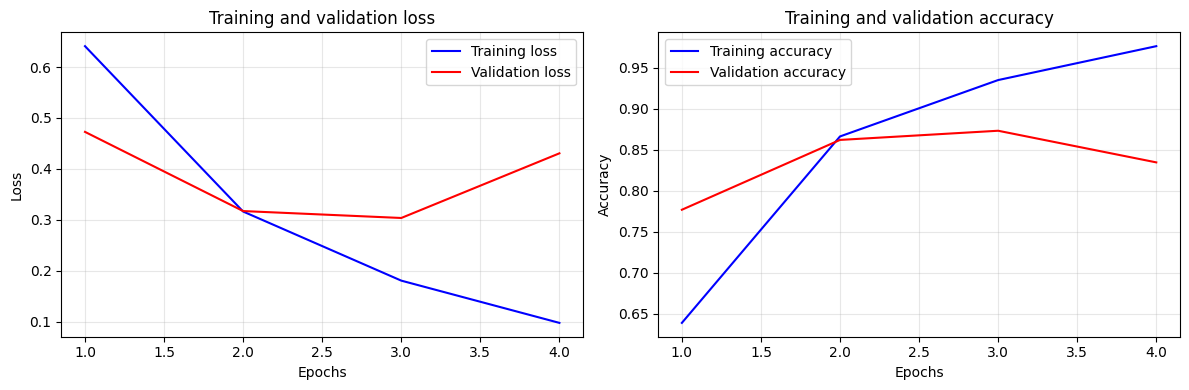

In [93]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

# Loss: train vs validation
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-', label='Training loss')
plt.plot(epochs, history.history['val_loss'], 'r-', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and validation loss')
plt.grid(True, alpha=0.3)

# Accuracy: train vs validation
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'b-', label='Training accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'r-', label='Validation accuracy')
plt.xlabel('Epochs')

plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and validation accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
help(keras.Sequential)
help(layers.Embedding)
help(layers.Dense)
help(model.fit)

Help on class Sequential in module keras.src.models.sequential:

class Sequential(keras.src.models.model.Model)
 |  Sequential(*args, **kwargs)
 |
 |  `Sequential` groups a linear stack of layers into a `Model`.
 |
 |  Examples:
 |
 |  ```python
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |
 |  # Note that you can also omit the initial `Input`.
 |  # In that case the model doesn't have any weights until the first call
 |  # to a training/evaluation method (since it isn't yet built):
 |  model = keras.Sequential()
 |  model.add(keras.layers.Dense(8))
 |  model.add(keras.layers.Dense(4))
 |  # model.weights not created yet
 |
 |  # Whereas if you specify an `Input`, the model gets built
 |  # continuously as you are adding layers:
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |  len(model.weights)  # Returns "2"
 |
 |  # When using the delayed-build pattern (no 

In [23]:
!nvidia-smi


Fri Mar 13 12:47:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.00                 Driver Version: 561.00         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   65C    P3             11W /   42W |      72MiB /   8188MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----